In [1]:
## Initial exploration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
## importando as bases 
train = pd.read_csv('../data/raw/train.csv')
test  = pd.read_csv('../data/raw/test.csv')

In [3]:
print("base de treino: ", train.shape)
print("base de teste: ", test.shape)

base de treino:  (891, 12)
base de teste:  (418, 11)


In [4]:
train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [5]:
test.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


# 01. Analisando a base de treino

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
## Copiando o dado
train_data = train.copy()

In [10]:
## Qual a distribuição de faixa etaria por genero
train_data['Age'] = train_data['Age'].fillna(-1)
bins = [-1,0,10,20,30,40,50,60,70,80,90]
labels = ['Missing','0-10','10-20','20-30','30-40','40-50','50-60','60-70','70-80','>90']
train_data['faixa_etaria'] = pd.cut(train_data['Age'], bins = bins, labels = labels,include_lowest=True)

In [11]:
train_data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,faixa_etaria
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,20-30
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,30-40


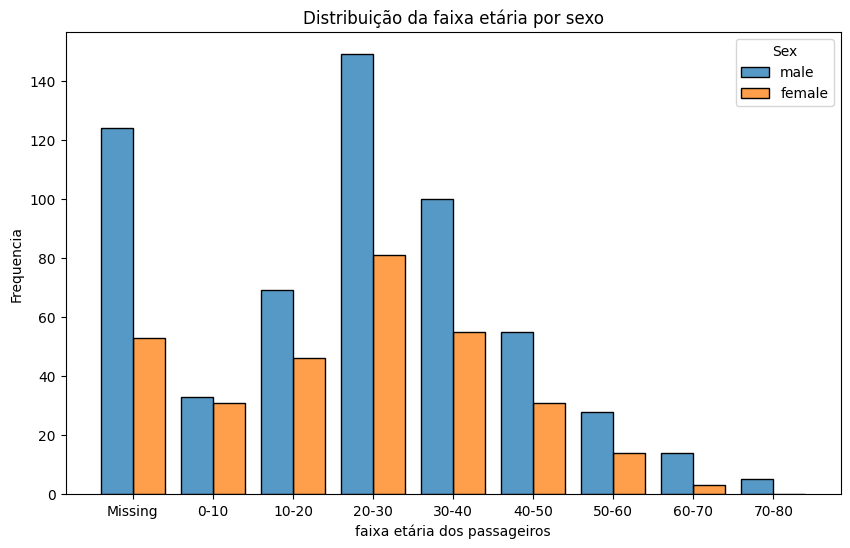

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(data=train_data,x='faixa_etaria', hue ='Sex', multiple="dodge", shrink=0.8)
sns.set_palette("muted")
plt.title('Distribuição da faixa etária por sexo')
plt.xlabel('faixa etária dos passageiros')
plt.ylabel("Frequencia")
plt.show()

##### análise do gráfico de faixa etária: Notamos que o perfil dos passageiros por sexo e idade concentram em uma faixa etárias mais jovem entre 20-40 anos , sendo os homens a maioria da população de passeiros,e podemos notar um número expressivo sem informação de idade.

In [60]:
train_data['Survived_pct'] = train_data['Survived'] * 100

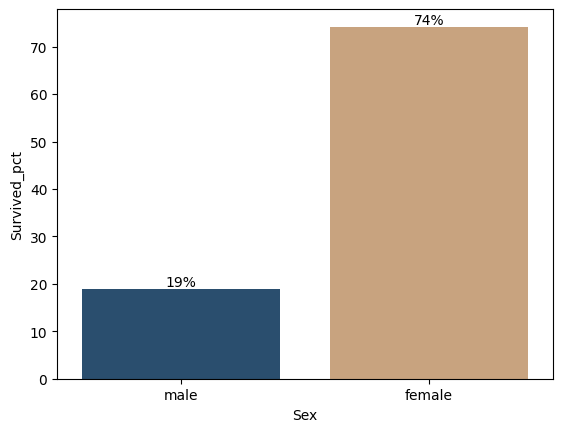

In [61]:
ax = sns.barplot(data=train_data, x='Sex', y='Survived_pct',hue = 'Sex', palette=['#1f4e79', '#d4a373'],
    legend=False,errorbar=None)
ax.bar_label(ax.containers[0], fontsize=10,fmt='%.0f%%');
ax.bar_label(ax.containers[1], fontsize=10,fmt='%.0f%%');

### O grafico acima mostra que a taxa de sobrevivencia é mais alta no sexo feminino.

In [50]:
mapping = {1: '1.Upper', 2:'2.Middle', 3:'3.Lower'}
train_data['Classe'] = train_data['Pclass'].map(mapping)

In [16]:
ct = pd.crosstab(train_data['Classe'], train_data['Survived'], normalize='index')*100

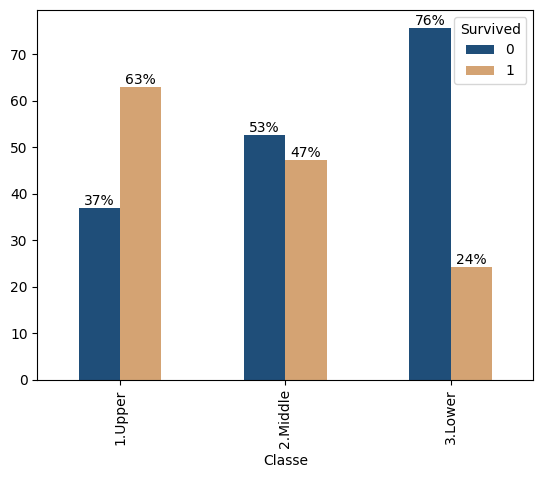

In [17]:
ax = ct.plot(kind='bar', color=['#1f4e79', '#d4a373'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%')

#### Analise: Das três classes podemos notar que tivemos mais sobreviventes da classe 1 e menos sobreviventes na classe 3.

In [ ]:
## SibSp :# of siblings / spouses aboard the Titanic - parentes ou conjugues.
train_data.groupby('SibSp')['PassengerId'].count()

SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: PassengerId, dtype: int64

In [24]:
sbs = pd.crosstab(train_data['SibSp'], train_data['Survived'], normalize='index')*100
sbs

Survived,0,1
SibSp,,
0,65.460526,34.539474
1,46.411483,53.588517
2,53.571429,46.428571
3,75.000000,25.000000
4,83.333333,16.666667
5,100.000000,0.000000
8,100.000000,0.000000


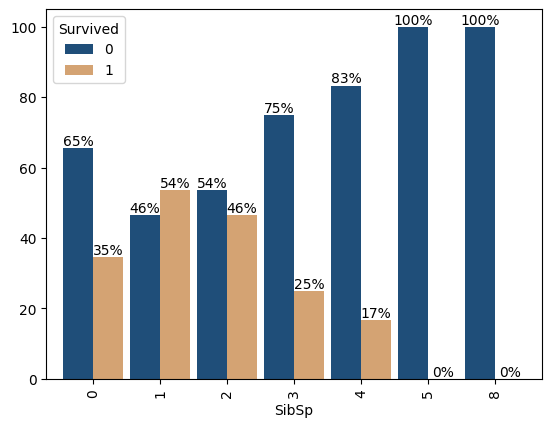

In [ ]:
ax = sbs.plot(kind='bar', color=['#1f4e79', '#d4a373'], width=0.9)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%')

#### Podemos notar que quanto mais parentes o passageiro tem , menores a chances dele sobreviver. A melhora taxa de sobrevivência é se você tem um parente/conjugue.

In [27]:
train_data[train_data.SibSp == 8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,faixa_etaria,Survived_pct,Classe
159,160,0,3,"Sage, Master. Thomas Henry",male,-1.0,8,2,CA. 2343,69.55,NaN,S,Missing,0,3.Lower
180,181,0,3,"Sage, Miss. Constance Gladys",female,-1.0,8,2,CA. 2343,69.55,NaN,S,Missing,0,3.Lower
201,202,0,3,"Sage, Mr. Frederick",male,-1.0,8,2,CA. 2343,69.55,NaN,S,Missing,0,3.Lower
324,325,0,3,"Sage, Mr. George John Jr",male,-1.0,8,2,CA. 2343,69.55,NaN,S,Missing,0,3.Lower
792,793,0,3,"Sage, Miss. Stella Anna",female,-1.0,8,2,CA. 2343,69.55,NaN,S,Missing,0,3.Lower
846,847,0,3,"Sage, Mr. Douglas Bullen",male,-1.0,8,2,CA. 2343,69.55,NaN,S,Missing,0,3.Lower
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,-1.0,8,2,CA. 2343,69.55,NaN,S,Missing,0,3.Lower


<Axes: xlabel='Fare', ylabel='Density'>

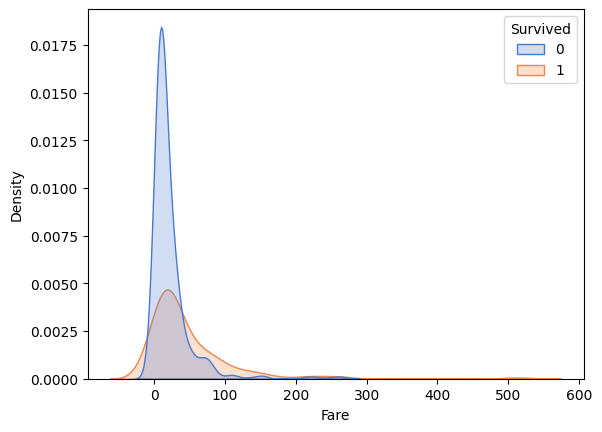

In [34]:
## Distribuição do Fare.
sns.kdeplot(data=train_data, x='Fare', hue='Survived', fill=True)


In [38]:
print("Média: ", train_data['Fare'].mean())
print("Mediana: ", train_data['Fare'].median())
print("Moda: ", train_data['Fare'].mode()[0])

Média:  32.204207968574636
Mediana:  14.4542
Moda:  8.05


##### Podemos notar pelo gráfico e pelos valores de média, mediana e moda que temos uma distribuição assimétrica a direita(moda < mediana < média). Notamos que em tafiras de valores mais baixos temos maior concentração de não sobreviventes.

In [52]:
emb = pd.crosstab([train_data['Embarked'], train_data['Classe']], train_data['Survived'], normalize='index')*100
emb

Survived                   0          1
Embarked Classe                        
C        1.Upper   30.588235  69.411765
         2.Middle  47.058824  52.941176
         3.Lower   62.121212  37.878788
Q        1.Upper   50.000000  50.000000
         2.Middle  33.333333  66.666667
         3.Lower   62.500000  37.500000
S        1.Upper   41.732283  58.267717
         2.Middle  53.658537  46.341463
         3.Lower   81.019830  18.980170

In [53]:
emb =emb.reset_index()
emb =emb.melt(id_vars=['Embarked', 'Classe'],
                var_name='Survived',
                value_name='Percentage')


In [54]:
emb

,Embarked,Classe,Survived,Percentage
0,C,1.Upper,0,30.588235
1,C,2.Middle,0,47.058824
2,C,3.Lower,0,62.121212
3,Q,1.Upper,0,50.000000
4,Q,2.Middle,0,33.333333
5,Q,3.Lower,0,62.500000
6,S,1.Upper,0,41.732283
7,S,2.Middle,0,53.658537
8,S,3.Lower,0,81.019830
9,C,1.Upper,1,69.411765


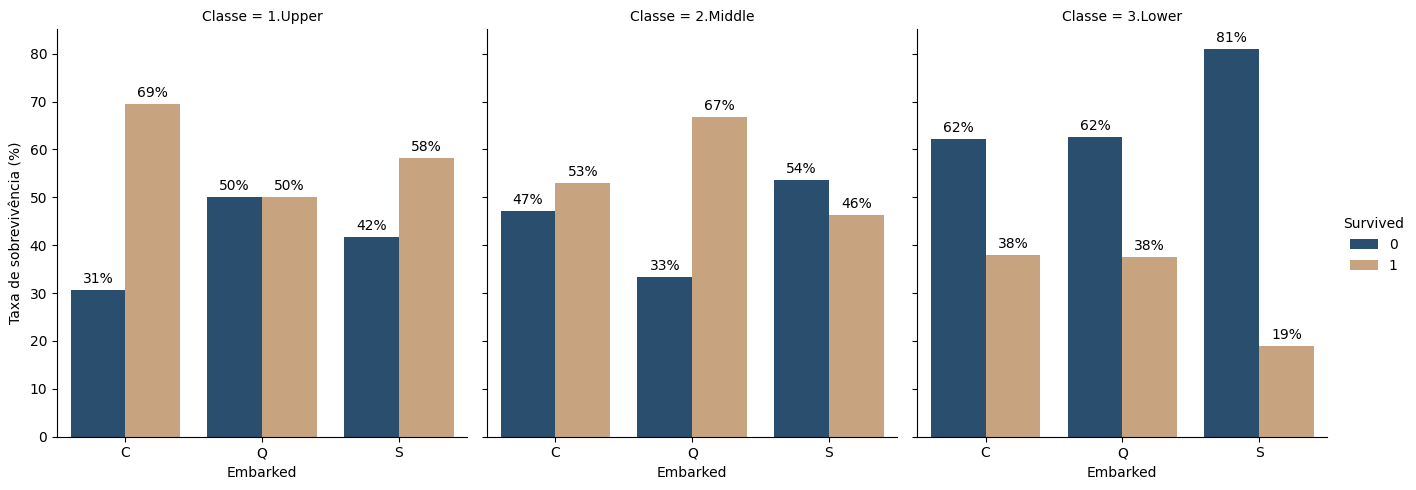

In [59]:
g = sns.catplot(
    data=emb,
    x='Embarked',
    y='Percentage',
    hue='Survived',
    col='Classe',
    kind='bar',
    palette=['#1f4e79', '#d4a373'],
    height=5,
    aspect=0.9
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', padding=3)

g.set_axis_labels("Embarked", "Taxa de sobrevivência (%)")


##### Passageiros que estão na terceira classe tem mais chances de não sobreviver nos três pontos de embarque. Na primeira classe o embarque no C teve mais sobreviventes do que os outros portos. Já na classe média, o embarque no porto Q teve mais sobreviventes.